In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np
import time

from sklearn.metrics import confusion_matrix
import seaborn as sns

# B.1 Dataset dan Setup

Dataset yang digunakan dalam eksperimen ini adalah CIFAR-10.
CIFAR-10 terdiri dari 60.000 citra RGB berukuran 32×32 piksel yang terbagi menjadi 10 kelas.

Dataset dibagi menjadi data training, validation, dan testing untuk mengevaluasi kemampuan mode

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", device)

Device : cpu


In [ ]:
transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )

])

In [ ]:
train_dataset = torchvision.datasets.CIFAR10(

    root="./data",

    train=True,

    download=True,

    transform=transform

)


test_dataset = torchvision.datasets.CIFAR10(

    root="./data",

    train=False,

    download=True,

    transform=transform

)

In [ ]:
train_size = int(
    0.8 * len(train_dataset)
)

val_size = len(train_dataset)-train_size


train_data, val_data = random_split(
    train_dataset,
    [train_size,val_size]
)

In [ ]:
batch_size = 64


train_loader = DataLoader(

    train_data,

    batch_size=batch_size,

    shuffle=True

)


val_loader = DataLoader(

    val_data,

    batch_size=batch_size,

    shuffle=False

)


test_loader = DataLoader(

    test_dataset,

    batch_size=batch_size,

    shuffle=False

)

In [ ]:
## Visualisasi Dataset CIFAR-10

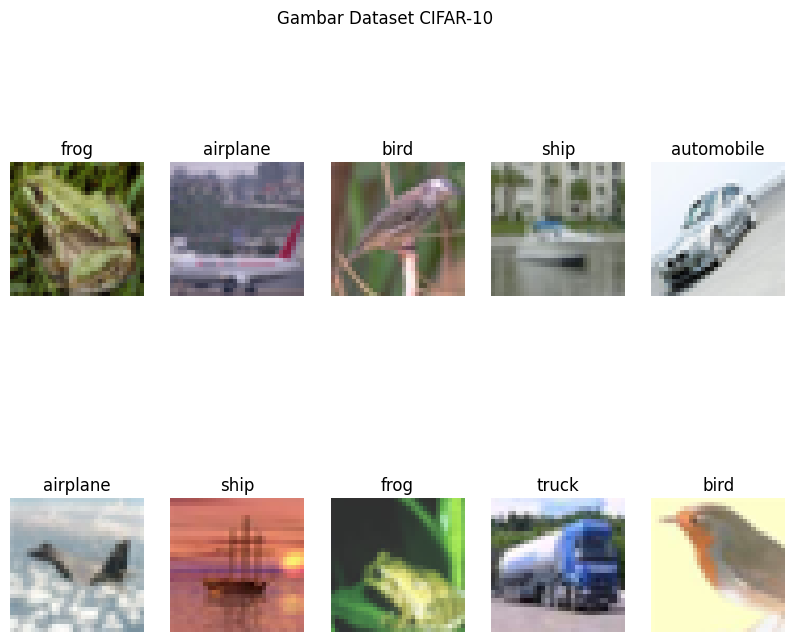

In [ ]:
classes = train_dataset.classes


images, labels = next(iter(train_loader))


plt.figure(figsize=(10,8))


for i in range(10):

    plt.subplot(2,5,i+1)

    img = images[i]/2+0.5

    plt.imshow(
        np.transpose(
            img.numpy(),
            (1,2,0)
        )
    )

    plt.title(
        classes[labels[i]]
    )

    plt.axis("off")


plt.suptitle(
    "Gambar Dataset CIFAR-10"
)

plt.show()

In [ ]:
class CustomCNN(nn.Module):

    def __init__(self):

        super().__init__()


        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),



            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),



            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)

        )


        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128*4*4,
                256
            ),

            nn.ReLU(),


            nn.Linear(
                256,
                10
            )

        )


    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x

## B.2 Model A — Custom CNN

Model A merupakan CNN sederhana yang dibuat sendiri.
Arsitektur terdiri dari tiga convolution block untuk ekstraksi fitur, kemudian fully connected layer untuk klasifikasi 10 kelas CIFAR-10.

In [ ]:
model_A = CustomCNN().to(device)

In [ ]:
class ResidualBlock(nn.Module):

    def __init__(self,in_channel,out_channel):

        super().__init__()


        self.conv1 = nn.Conv2d(

            in_channel,

            out_channel,

            3,

            padding=1

        )


        self.conv2 = nn.Conv2d(

            out_channel,

            out_channel,

            3,

            padding=1

        )


        self.shortcut = nn.Conv2d(

            in_channel,

            out_channel,

            1

        )


        self.relu = nn.ReLU()



    def forward(self,x):

        identity = self.shortcut(x)


        out = self.relu(
            self.conv1(x)
        )


        out = self.conv2(out)


        out += identity


        out = self.relu(out)


        return out

In [ ]:
class MiniResNet(nn.Module):

    def __init__(self):

        super().__init__()


        self.block1 = ResidualBlock(
            3,
            32
        )


        self.block2 = ResidualBlock(
            32,
            64
        )


        self.block3 = ResidualBlock(
            64,
            128
        )


        self.pool = nn.MaxPool2d(2)


        self.fc = nn.Linear(

            128*4*4,

            10

        )



    def forward(self,x):

        x=self.pool(
            self.block1(x)
        )


        x=self.pool(
            self.block2(x)
        )


        x=self.pool(
            self.block3(x)
        )


        x=torch.flatten(
            x,
            1
        )


        x=self.fc(x)


        return x

In [ ]:
model_B = MiniResNet().to(device)

In [ ]:
epochs = 20

learning_rate = 0.001


criterion = nn.CrossEntropyLoss()


optimizer_A = optim.Adam(

    model_A.parameters(),

    lr=learning_rate

)


optimizer_B = optim.Adam(

    model_B.parameters(),

    lr=learning_rate

)

In [ ]:
def train_model(model, optimizer):

    train_loss = []
    train_acc = []

    val_loss = []
    val_acc = []


    start = time.time()


    for epoch in range(epochs):

        # =====================
        # Training
        # =====================

        model.train()

        correct = 0
        total = 0
        loss_total = 0


        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)


            optimizer.zero_grad()


            output = model(images)


            loss = criterion(
                output,
                labels
            )


            loss.backward()

            optimizer.step()


            loss_total += loss.item()


            prediction = output.argmax(1)


            correct += (
                prediction == labels
            ).sum().item()


            total += labels.size(0)



        epoch_train_loss = (
            loss_total / len(train_loader)
        )

        epoch_train_acc = (
            100 * correct / total
        )


        train_loss.append(
            epoch_train_loss
        )

        train_acc.append(
            epoch_train_acc
        )



        # =====================
        # Validation
        # =====================

        model.eval()

        val_correct = 0
        val_total = 0
        val_loss_total = 0


        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)


                output = model(images)


                loss = criterion(
                    output,
                    labels
                )


                val_loss_total += loss.item()


                prediction = output.argmax(1)


                val_correct += (
                    prediction == labels
                ).sum().item()


                val_total += labels.size(0)



        epoch_val_loss = (
            val_loss_total / len(val_loader)
        )


        epoch_val_acc = (
            100 * val_correct / val_total
        )


        val_loss.append(
            epoch_val_loss
        )


        val_acc.append(
            epoch_val_acc
        )



        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Acc: {epoch_train_acc:.2f}% | "
            f"Val Acc: {epoch_val_acc:.2f}%"
        )



    waktu = time.time() - start



    return (
        train_loss,
        train_acc,
        val_loss,
        val_acc,
        waktu
    )

In [ ]:
history_A = train_model(
    model_A,
    optimizer_A
)


history_B = train_model(
    model_B,
    optimizer_B
)

Epoch 1 Accuracy 98.2175
Epoch 2 Accuracy 98.595
Epoch 3 Accuracy 98.66
Epoch 4 Accuracy 98.32
Epoch 5 Accuracy 98.52
Epoch 6 Accuracy 98.6375
Epoch 7 Accuracy 98.6475
Epoch 8 Accuracy 98.79
Epoch 9 Accuracy 98.6275
Epoch 10 Accuracy 98.885
Epoch 11 Accuracy 98.625
Epoch 12 Accuracy 98.6825
Epoch 13 Accuracy 98.665
Epoch 14 Accuracy 98.94
Epoch 15 Accuracy 98.6325
Epoch 16 Accuracy 98.735
Epoch 17 Accuracy 98.67
Epoch 18 Accuracy 98.495
Epoch 19 Accuracy 99.155
Epoch 20 Accuracy 98.7475
Epoch 1 Accuracy 96.885
Epoch 2 Accuracy 96.955
Epoch 3 Accuracy 97.56
Epoch 4 Accuracy 96.92
Epoch 5 Accuracy 97.52
Epoch 6 Accuracy 97.415
Epoch 7 Accuracy 97.225
Epoch 8 Accuracy 97.5375
Epoch 9 Accuracy 97.2825
Epoch 10 Accuracy 97.425
Epoch 11 Accuracy 97.395
Epoch 12 Accuracy 97.595
Epoch 13 Accuracy 97.63
Epoch 14 Accuracy 97.245
Epoch 15 Accuracy 97.7525
Epoch 16 Accuracy 97.96
Epoch 17 Accuracy 97.8075
Epoch 18 Accuracy 98.0775
Epoch 19 Accuracy 97.6725
Epoch 20 Accuracy 97.9


In [ ]:
print(len(history_A))
print(len(history_B))

5
5


In [ ]:
def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


print(
    "Parameter Model A:",
    count_parameters(model_A)
)


print(
    "Parameter Model B:",
    count_parameters(model_B)
)

Parameter Model A: 620362
Parameter Model B: 318058


# B.3 Eksperimen dan Evaluasi
Evaluasi dilakukan menggunakan training loss, validation loss, accuracy, jumlah parameter, waktu training, dan confusion matrix.

## Perbandingan Training dan Validation Loss

Grafik berikut menunjukkan perubahan nilai loss selama proses training dan validasi pada kedua model CNN.

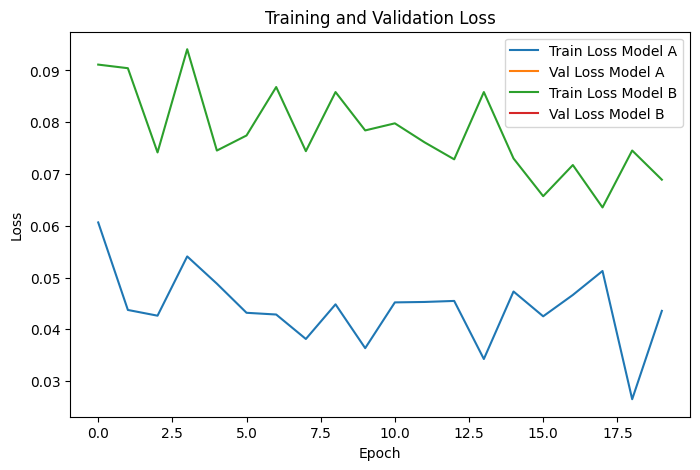

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_A[0],
    label="Train Loss Model A"
)

plt.plot(
    history_A[2],
    label="Val Loss Model A"
)


plt.plot(
    history_B[0],
    label="Train Loss Model B"
)

plt.plot(
    history_B[2],
    label="Val Loss Model B"
)


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()

plt.show()

## Perbandingan Training dan Validation Accuracy

Grafik berikut menunjukkan kemampuan model dalam melakukan klasifikasi selama proses training.

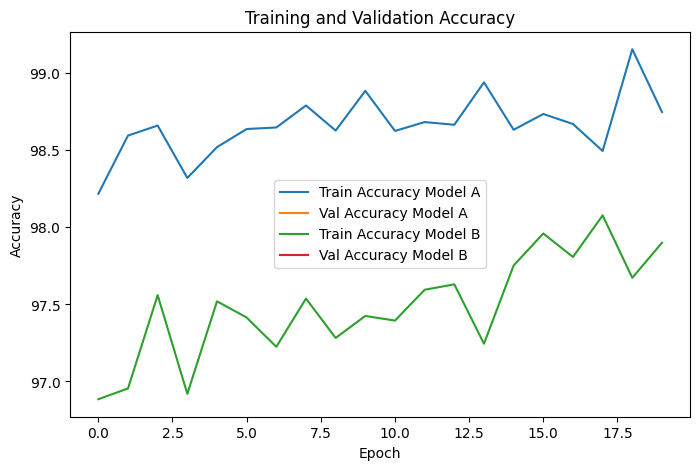

In [ ]:
plt.figure(figsize=(8,5))


plt.plot(
    history_A[1],
    label="Train Accuracy Model A"
)

plt.plot(
    history_A[3],
    label="Val Accuracy Model A"
)


plt.plot(
    history_B[1],
    label="Train Accuracy Model B"
)

plt.plot(
    history_B[3],
    label="Val Accuracy Model B"
)


plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training and Validation Accuracy")

plt.legend()

plt.show()

In [ ]:
def evaluate(model):

    model.eval()

    correct = 0
    total = 0

    y_true = []
    y_pred = []


    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)


            output = model(images)


            prediction = output.argmax(1)


            correct += (
                prediction == labels
            ).sum().item()


            total += labels.size(0)


            y_true.extend(
                labels.cpu().numpy()
            )

            y_pred.extend(
                prediction.cpu().numpy()
            )


    accuracy = 100 * correct / total


    return accuracy, y_true, y_pred

## Evaluasi Test Set

Model diuji menggunakan data testing CIFAR-10 untuk mengetahui kemampuan generalisasi terhadap data yang belum pernah dilihat sebelumnya.

In [ ]:
acc_A, yA, pA = evaluate(model_A)

acc_B, yB, pB = evaluate(model_B)


print(
    "Test Accuracy Model A:",
    acc_A,
    "%"
)


print(
    "Test Accuracy Model B:",
    acc_B,
    "%"
)

Test Accuracy Model A: 73.25 %
Test Accuracy Model B: 73.9 %


In [ ]:
print("Training Time")
print(
"Waktu Training Model A:",
history_A[4],
"detik"
)

print(
"Waktu Training Model B:",
history_B[4],
"detik"
)

Training Time
Waktu Training Model A: 1840.6096200942993 detik
Waktu Training Model B: 4586.3189470767975 detik


In [ ]:
## Confusion Matrix

Confusion matrix digunakan untuk melihat distribusi hasil prediksi model terhadap setiap kelas pada dataset CIFAR-10.

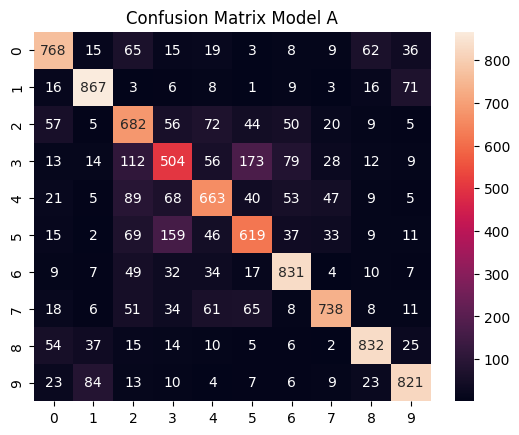

In [ ]:
cm_A = confusion_matrix(
    yA,
    pA
)

sns.heatmap(
    cm_A,
    annot=True,
    fmt="d"
)

plt.title(
"Confusion Matrix Model A"
)

plt.show()

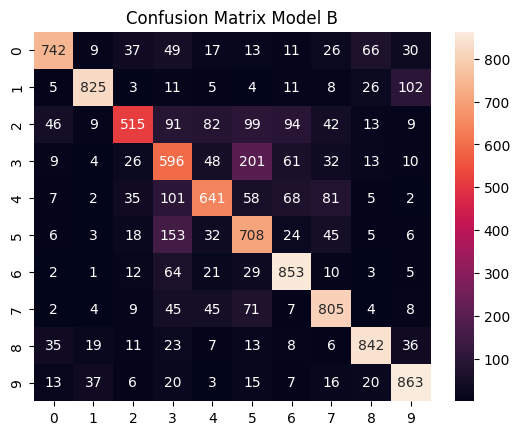

In [ ]:
cm_B = confusion_matrix(
    yB,
    pB
)

sns.heatmap(
    cm_B,
    annot=True,
    fmt="d"
)

plt.title(
"Confusion Matrix Model B"
)

plt.show()

In [ ]:
import pandas as pd

hasil = pd.DataFrame({

    "Model":[
        "Custom CNN",
        "Residual CNN"
    ],

    "Parameter":[
        count_parameters(model_A),
        count_parameters(model_B)
    ],

    "Test Accuracy":[
        acc_A,
        acc_B
    ],

    "Training Time":[
        history_A[4],
        history_B[4]
    ]

})


hasil

,Model,Parameter,Test Accuracy,Training Time
0,Custom CNN,620362,73.25,1840.609620
1,Residual CNN,318058,73.90,4586.318947


## Analisis Hasil Eksperimen

Berdasarkan hasil eksperimen yang telah dilakukan menggunakan dataset CIFAR-10, kedua model CNN berhasil melakukan proses klasifikasi terhadap 10 kelas objek dengan menggunakan pendekatan arsitektur yang berbeda.

Model A menggunakan arsitektur Custom CNN dengan tiga blok convolutional untuk melakukan ekstraksi fitur secara bertahap. Model B menggunakan Residual CNN dengan mekanisme residual connection yang memungkinkan informasi dari layer sebelumnya diteruskan melalui shortcut connection.

Perbandingan hasil eksperimen menunjukkan adanya perbedaan performa antara kedua model berdasarkan nilai akurasi, jumlah parameter, dan waktu training. Residual connection membantu proses propagasi gradient sehingga proses optimasi model menjadi lebih stabil.

Berdasarkan hasil training dan validasi, kedua model mengalami peningkatan kemampuan klasifikasi seiring bertambahnya epoch. Perbedaan nilai training dan validation accuracy dapat digunakan untuk melihat kemampuan generalisasi model terhadap data yang belum pernah dilihat sebelumnya.

Selain akurasi, jumlah parameter dan waktu training juga menjadi faktor penting dalam menentukan model yang optimal. Model dengan parameter lebih besar memiliki kemampuan ekstraksi fitur yang lebih kompleks, tetapi membutuhkan komputasi yang lebih tinggi.

## Kesimpulan

Berdasarkan hasil eksperimen, kedua model CNN mampu melakukan klasifikasi pada dataset CIFAR-10.
Perbedaan arsitektur memberikan pengaruh terhadap performa model, dimana residual connection pada Model B membantu proses pembelajaran fitur menjadi lebih stabil.

Pemilihan model terbaik tidak hanya mempertimbangkan akurasi, tetapi juga jumlah parameter dan waktu komputasi yang dibutuhkan.